# Probability & Statistics Lab 1: Naive Bayes Classifier

Work breakdown:
-   *Milana Katrych*;
-   *Zhurayev Lev*;
-   *Vertyporokh Anton*.

## Introduction

During the first three weeks, you learned a couple of essential notions
and theorems, and one of the most important among them is the **Bayes
theorem**:

$$
\mathsf P(A \mid B) = \frac{\mathsf P(A)\mathsf P(B \mid A)}{\mathsf P(B)}.
$$


**Naive Bayes Classifier** is a simple algorithm, which is based on
Bayes theorem and used for solving classification problems.

**Classification problem** is a problem in which an observation has to
be classified in one of the $n$ classes based on its similarity with
observations in each class.

It is a **probabilistic classifier**, which means it predicts based on
the probability of an observation belonging to each class. To compute
it, this algorithm uses **Bayes' formula** as:
$$
\mathsf P (\text{class}_i \mid \text{observation}) = \frac{\mathsf P(\text{class}_i) \mathsf P(\text{observation} \mid \text{class}_i)}{\mathsf P(\text{observation})}. \quad \quad (1)
$$
Breaking down the pieces of the formula,
- $\mathsf P(\text{class}_i)$ is referred to as a **prior** [distribution]: it provides initial class probabilities, influenced by prior beliefs about the problem.
- $\mathsf P(\text{observation} \mid \text{class}_i)$ is the **likelihood**: it tells how likely observations are for a chosen class.
- $\mathsf P(\text{observation})$ is the **evidence**; usually isn't computed directly and used as a normalization constant s.t. sum of $\mathsf P (\text{class}_i \mid \text{observation})$ for all classes is $1$.


This lab focuses on binary classification of text. Text can be considered a sequence of observations/features, with many ways to split it into individual/elementary features. Here, we split the text by words, and one word is considered a feature $\text{feature}_j$:
$\mathsf P(\text{text}) = \mathsf P(\text{features}_1, \text{feature}_2, \dots, \text{feature}_N) = \mathsf P(\text{features}_1)\cdot \mathsf P(\text{feature}_2 \mid \text{feature}_1) \cdot \mathsf P(\text{feature}_3 \mid (\text{feature}_1, \text{feature}_2)) \dots.$

However, modeling such long conditionals is complex, compute-intensive, and requires lots of data.

One way to deal with this is to assume independence, where one can write: $\mathsf P(\text{text}) = \prod_{j=1}^N \mathsf P(\text{feature}_j).$
Or, one could assume the dependence only on the previous word, which will be explored in the additional task!

$\mathsf P(\text{feature}_j)$ is unknown, and we estimate it empirically using the training data split. The empirical probability of some feature $x$ would be $\frac{\text{\# of } x}{\text{total \# of features}}.$
Note that such an approach would turn $\mathsf P(\text{text})$ to $0$ for any completely new feature (as its count among data is zero), which is undesirable.
A common way to deal with this is [Laplace smoothing](https://en.wikipedia.org/wiki/Additive_smoothing). No need to dive deeply into this now, as you will develop a better intuition as you progress through the course.
In this lab, you shall apply Laplace smoothing to both class priors and feature ($\log$–)probabilities.

#### Implementation note

Instead of storing and calculating probabilities directly, many ML solutions prefer computations in $\log$ domain. One of the reasons is numerical stability, which shows up in $\prod_{j=1}^N \mathsf P(\text{feature}_j)$:
each $\mathsf P(\text{feature}_j) \in (0, 1)$ in practice, resulting in tiny final product, which floating-point numbers the computer uses can't store as accurately.
However, in the logarithmic domain even $10^{-100}$ corresponds to an order of magnitude of $-100$.

So, let's rewrite the equation we estimate:
$$
\log [\mathsf P (\text{class}_i \mid \text{observation})] = \underbrace{\log[\mathsf P(\text{class}_i)] + \sum_{j=1}^N \log[\mathsf P(\text{feature}_j)]}_{\text{used to be a numerator, } L_i} - \overbrace{\log[\mathsf P(\text{observation})]}^{\text{used to be a denominator, log-evidence}}. \quad \quad (2)
$$


[A video example of a Naive Bayes](https://www.youtube.com/watch?v=O2L2Uv9pdDA).


### Outline of the work

1.  **Data preprocessing** (1 point)
2.  **Data visualization** (1 point)
3.  **Classifier implementation from scratch** (1.5 points)
4.  **Measurements of effectiveness of your classifier** (1.5 points)
5.  **Additional task** (up to 2 points, optional)


*Please submit a pre-executed `.ipynb` notebook for easier evaluation.*


### Data preprocessing

In [ ]:
import pathlib
import pandas as pd
import numpy as np
import re
from collections import defaultdict


class Dataset:
    def __init__(self, dataset_dir_path: pathlib.Path):
        self.train_df = pd.read_csv(dataset_dir_path / "train.csv")
        self.test_df = pd.read_csv(dataset_dir_path / "test.csv")

        self.bag_of_words_per_label_id: dict[int, dict[str, int]] = {}
        self.bag_of_log_probabilities_per_label_id: dict[int, dict[str, float]] = {}

        self.stop_words_set: set[str] = set()

    def preprocess_text(self, stop_words: list[str]) -> None:
        """
        Adds "label-id" (starting with 0) and "useful-words" columns to dataframes.
        Useful words are the ones that aren't in the stop words list.
        Remove the punctuation, map all the text to one register (e.g., lowercase).

        You may add custom preprocessing if it's justified!
        """
        self.stop_words_set = set(stop_words)
        unique_labels = sorted(self.train_df["label"].unique())
        label_to_id = {label: index for index, label in enumerate(unique_labels)}

        for df in (self.train_df, self.test_df):
            df["label-id"] = df["label"].map(label_to_id)
            df["useful-words"] = df["tweet"].apply(self._clean_and_split)

    def calculate_classes_prior(self, smoothing_alpha: float) -> np.ndarray:
        """
        :param smoothing_alpha: parameter of Laplace smoothing.
        :return: distribution of classes after smoothing, starting with label-id 0.
        """
        num_classes = self.train_df["label-id"].nunique()
        counts = self.train_df["label-id"].value_counts().sort_index()
        total = len(self.train_df)
        priors = (counts + smoothing_alpha) / (total + smoothing_alpha * num_classes)
        return priors.to_numpy()

    def compute_bag_of_words(self) -> None:
        """
        Counts the number of occurrences of each word per label id and updates `self.bag_of_words_per_label_id`.

        Bag of words intro: https://machinelearningmastery.com/gentle-introduction-bag-words-model/.
        Advice: you may use `collections.defaultdict` (https://docs.python.org/3/library/collections.html#collections.defaultdict).
        """
        bag = defaultdict(lambda: defaultdict(int))
        for label_id, words in zip(self.train_df["label-id"], self.train_df["useful-words"]):
            for word in words:
                bag[label_id][word] += 1
        self.bag_of_words_per_label_id = {key: dict(value) for key, value in bag.items()}

    def compute_bag_of_log_probabilities(self, smoothing_alpha: float) -> float:
        """
        Uses `self.bag_of_words_per_label_id` and updates `self.bag_of_log_probabilities_per_label_id`.
        `self.bag_of_log_probabilities_per_label_id` should store log[P(feature_j)].

        :param smoothing_alpha: parameter of Laplace smoothing.
        :return the log-probability of a new(previously unseen) feature, necessary for evaluation on the test set.
        """
        vocab = set()
        for bag in self.bag_of_words_per_label_id.values():
            vocab.update(bag.keys())
        vocab_size = len(vocab)
        for label_id, bag in self.bag_of_words_per_label_id.items():
            words = sum(bag.values())
            denominator = words + smoothing_alpha * vocab_size
            self.bag_of_log_probabilities_per_label_id[label_id] = {word: np.log((count + smoothing_alpha) / denominator) for word, count in bag.items()}
        total_words = sum(sum(bag.values()) for bag in self.bag_of_words_per_label_id.values())
        unseen_log_prob = np.log(smoothing_alpha / (total_words + smoothing_alpha * vocab_size))
        return unseen_log_prob

    def _clean_and_split(self, text: str) -> list[str]:
        text = text.lower()
        text = re.sub(r"[^a-z\s]", "", text)
        words = text.split()
        return [word for word in words if word not in self.stop_words_set]

discrimination_dataset_path = pathlib.Path("data/discrimination")  # change if needed.
discrimination_dataset = Dataset(discrimination_dataset_path)

labels = discrimination_dataset.train_df["label"].unique().tolist()
print(f"Labels are {labels}.")

Labels are ['discrim', 'neutral'].


Loading the stop words

In [2]:
stop_words_path = pathlib.Path("stop_words.txt")  # change if needed.

stop_words: list[str] = []
with open(stop_words_path) as f:
    for line in f:
        stop_words.append(line.strip())

print(f"Some of the stop words are {stop_words[:8]}.")

Some of the stop words are ['a', 'about', 'above', 'after', 'again', 'against', 'all', 'am'].


In [3]:
discrimination_dataset.preprocess_text(stop_words)

In [4]:
classes_alpha = 1.0
discrimination_dataset.calculate_classes_prior(classes_alpha)

array([0.07030482, 0.92969518])

In [5]:
discrimination_dataset.compute_bag_of_words()

In [6]:
features_alpha = 1.0
unseen_feature_log_prob = discrimination_dataset.compute_bag_of_log_probabilities(features_alpha)

### Data visualization

Visualize the dataset, its properties, etc. You may use external libraries such as `matplotlib`, `plotly`, etc. Data analysis could provide hints/ideas for downstream classifier evaluation.

We look at four things: how the classes are distributed, which words are frequent in each class, which words separate the classes, and how long the texts are. Each of them explains some later choice of the classifier or of the metric.

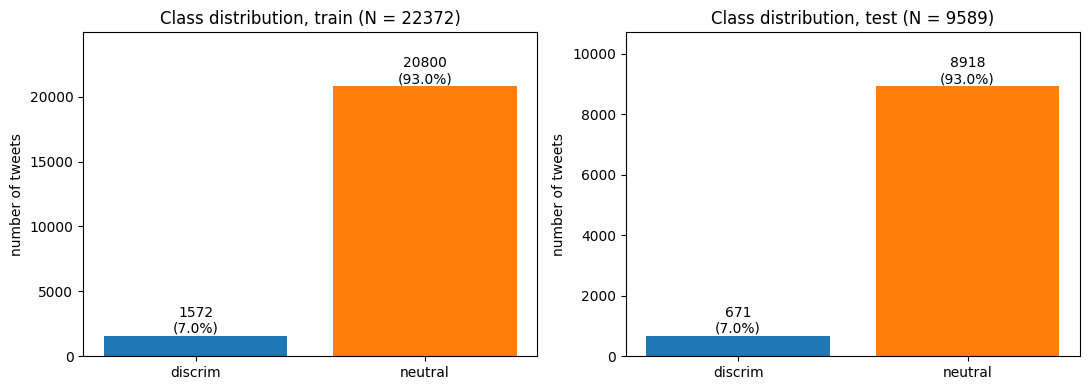

In [7]:
import matplotlib.pyplot as plt

train_df, test_df = discrimination_dataset.train_df, discrimination_dataset.test_df
id_to_label = {i: label for i, label in enumerate(sorted(labels))}
num_classes = len(id_to_label)
class_colors = plt.cm.tab10(np.arange(num_classes))

# 1. Class distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (split_name, df) in zip(axes, [("train", train_df), ("test", test_df)]):
    counts = df["label-id"].value_counts().sort_index()
    bars = ax.bar([id_to_label[i] for i in counts.index], counts.values, color=class_colors[counts.index])
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, count, f"{count}\n({count / len(df):.1%})",
                ha="center", va="bottom")
    ax.set_ylim(0, counts.max() * 1.2)
    ax.set_ylabel("number of tweets")
    ax.set_title(f"Class distribution, {split_name} (N = {len(df)})")
plt.tight_layout()
plt.show()

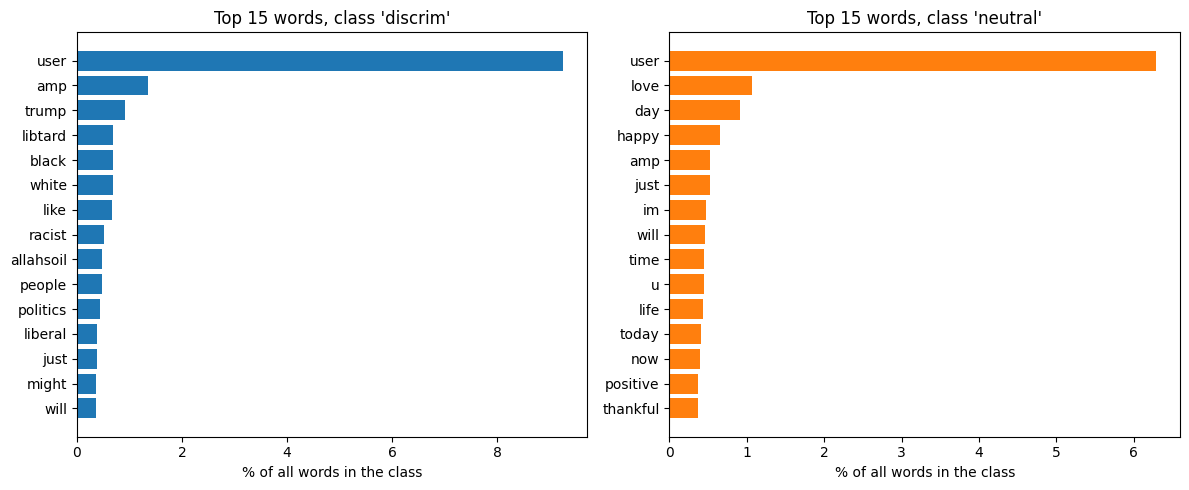

In [8]:
# 2. Most frequent words per class (as a share of all words in the class, so that classes of different size are comparable)
top_n = 15
fig, axes = plt.subplots(1, num_classes, figsize=(6 * num_classes, 5))
for label_id, ax in zip(range(num_classes), np.atleast_1d(axes)):
    bag = discrimination_dataset.bag_of_words_per_label_id[label_id]
    total_words = sum(bag.values())
    top = sorted(bag.items(), key=lambda item: -item[1])[:top_n]
    words, counts = zip(*top)
    ax.barh(words[::-1], [100 * c / total_words for c in counts[::-1]], color=class_colors[label_id])
    ax.set_xlabel("% of all words in the class")
    ax.set_title(f"Top {top_n} words, class '{id_to_label[label_id]}'")
plt.tight_layout()
plt.show()

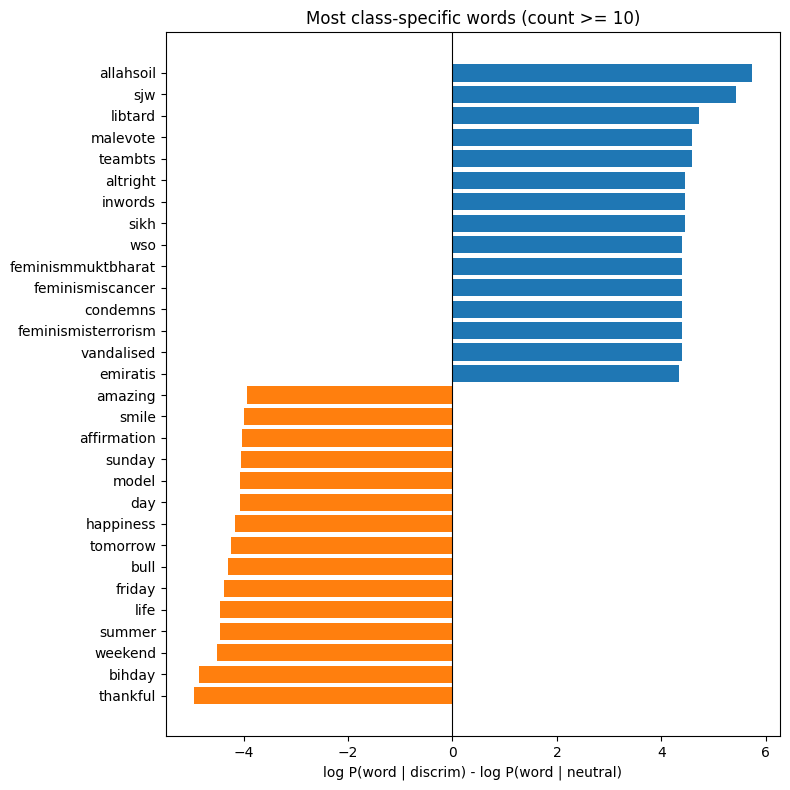

In [9]:
# 3. Words that separate the classes: log P(word | positive) - log P(word | other), with Laplace smoothing.
# This is exactly the quantity the classifier adds up for every word of a text (up to the prior).
# Very rare words give extreme ratios by chance, so we keep only words with at least `min_count` occurrences.
positive_id = sorted(labels).index("discrim") if "discrim" in labels else num_classes - 1
other_id = 1 - positive_id  # the task is binary
min_count, show_n, alpha = 10, 15, 1.0

bags = discrimination_dataset.bag_of_words_per_label_id
vocabulary = set(bags[0]) | set(bags[1])
n_positive, n_other = sum(bags[positive_id].values()), sum(bags[other_id].values())

rows = []
for word in vocabulary:
    c_pos, c_other = bags[positive_id].get(word, 0), bags[other_id].get(word, 0)
    if c_pos + c_other >= min_count:
        log_ratio = (np.log((c_pos + alpha) / (n_positive + alpha * len(vocabulary)))
                     - np.log((c_other + alpha) / (n_other + alpha * len(vocabulary))))
        rows.append((word, c_pos + c_other, log_ratio))
log_ratios = pd.DataFrame(rows, columns=["word", "count", "log_ratio"]).sort_values("log_ratio")

extreme = pd.concat([log_ratios.head(show_n), log_ratios.tail(show_n)])
plt.figure(figsize=(8, 8))
plt.barh(extreme["word"], extreme["log_ratio"],
         color=[class_colors[positive_id] if r > 0 else class_colors[other_id] for r in extreme["log_ratio"]])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel(f"log P(word | {id_to_label[positive_id]}) - log P(word | {id_to_label[other_id]})")
plt.title(f"Most class-specific words (count >= {min_count})")
plt.tight_layout()
plt.show()

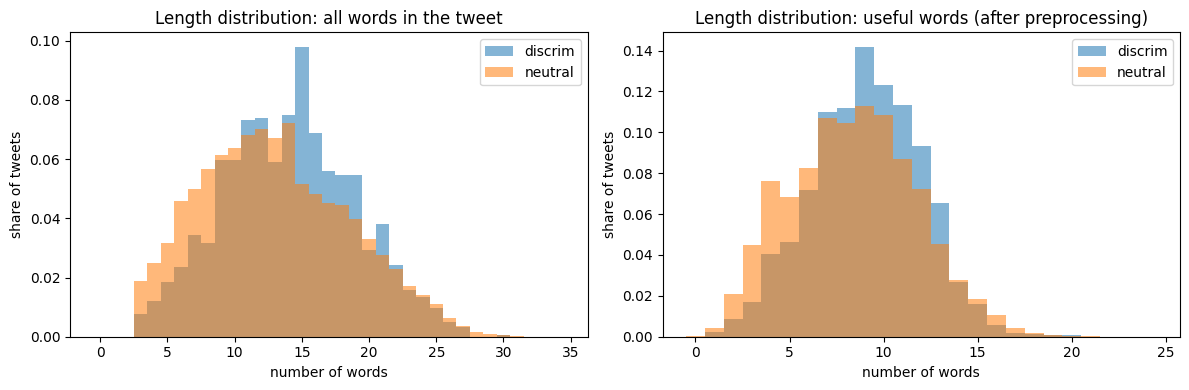

count  mean  std  min   25%   50%   75%   max
             label                                                   
raw words    discrim   1572.0  14.1  4.9  3.0  11.0  14.0  17.0  30.0
             neutral  20800.0  13.1  5.5  3.0   9.0  13.0  17.0  34.0
useful words discrim   1572.0   9.1  2.9  1.0   7.0   9.0  11.0  20.0
             neutral  20800.0   8.4  3.3  0.0   6.0   8.0  11.0  24.0

Tweets with no useful words (train): 0.04%
Vocabulary size (train): 31491
Share of test words never seen in train: 11.0%


In [10]:
# 4. Text lengths: all words in the raw tweet vs. useful words after preprocessing
raw_length = train_df["tweet"].str.split().str.len()
useful_length = train_df["useful-words"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, lengths, title in ((axes[0], raw_length, "all words in the tweet"),
                           (axes[1], useful_length, "useful words (after preprocessing)")):
    bins = np.arange(0, lengths.max() + 2) - 0.5
    for label_id in range(num_classes):
        ax.hist(lengths[train_df["label-id"] == label_id], bins=bins, density=True, alpha=0.55,
                color=class_colors[label_id], label=id_to_label[label_id])
    ax.set_xlabel("number of words")
    ax.set_ylabel("share of tweets")
    ax.set_title(f"Length distribution: {title}")
    ax.legend()
plt.tight_layout()
plt.show()

summary = pd.concat({"raw words": raw_length.groupby(train_df["label"]).describe(),
                     "useful words": useful_length.groupby(train_df["label"]).describe()})
display(summary.round(1))

train_vocabulary = {w for words in train_df["useful-words"] for w in words}
test_words = [w for words in test_df["useful-words"] for w in words]
print(f"Tweets with no useful words (train): {(useful_length == 0).mean():.2%}")
print(f"Vocabulary size (train): {len(train_vocabulary)}")
print(f"Share of test words never seen in train: {np.mean([w not in train_vocabulary for w in test_words]):.1%}")

#### What the plots show and why it matters

- **Class imbalance.** The positive class `discrim` is 1572 of 22372 tweets in train (7.0%) and 671 of 9589 in test (7.0%), so both splits have the same proportions. The prior $\mathsf P(\text{discrim})$ is small, and the classifier needs strong word evidence to overcome it. It also means that accuracy is misleading here, which is discussed in the evaluation section.
- **Frequent words.** The most frequent word in both classes is `user`: the dataset replaces every `@mention` with it (about 9% of the words in `discrim` and 6% in `neutral`). `amp` comes from the HTML-escaped `&amp;`. Both are artifacts of the data and say nothing about the topic. Apart from them, frequent words mostly describe the general mood of the class: `trump`, `black`, `white`, `racist`, `liberal` for `discrim`, and `love`, `day`, `happy`, `life`, `thankful` for `neutral`.
- **Class-specific words.** The log-ratio plot shows which words actually move the decision: a positive ratio pushes the text towards `discrim`, a negative one towards `neutral`. The `discrim` side is slang and insults (`libtard`, `sjw`, `altright`) and political or religious hashtags (`allahsoil`), many of them several words glued into one hashtag (`feminismiscancer`). The `neutral` side is everyday positive vocabulary (`amazing`, `smile`, `weekend`, `happiness`, `thankful`). So the model learns mostly the vocabulary and topics of each class, not hate speech as such. This is one reason why the labels are hard to predict from words alone.
- **Length.** Tweets are short: about 8-9 useful words after preprocessing (mean 9.1 for `discrim`, 8.4 for `neutral`). The two distributions overlap almost completely, so length does not separate the classes. There are few features per text, so one strong word can decide the answer. Short texts are also the reason why the bigram model in the additional task suffers from sparsity.
- **Vocabulary.** The train vocabulary has about 31 000 distinct words for 22 000 tweets, and 11% of the test words were never seen in train. This is why the `unseen_feature_log_prob` from the preprocessing part is needed. Only a handful of tweets (0.04%) are empty after stop-word removal; for them the classifier returns just the class prior, i.e. `neutral`.

### Classifier implementation

Recall equation $(2)$. You will manually calculate the *"used to be a numerator"* part, call it $L_i$, for each class, while log-evidence is numerically safely calculated from an array of log-domain per-class numerators.


In [11]:
def compute_log_evidence(per_label_log_domain_numerator: np.ndarray) -> float:
    return np.logaddexp.reduce(per_label_log_domain_numerator)

#### Derivation of log-evidence calculation

Fix a text and let $L_i = \log \mathsf P(\text{class}_i) + \sum_{j=1}^N \log \mathsf P(\text{feature}_j \mid \text{class}_i)$ be the log-domain numerator for class $i$, $i = 1, \dots, C$. Equation $(2)$ says

$$
\log \mathsf P(\text{class}_i \mid \text{text}) = L_i - \log \mathsf P(\text{text}).
$$

We do not know $\log \mathsf P(\text{text})$ (the log-evidence), but we know that the posterior is a valid probability distribution over the classes, so the probabilities sum to $1$:

$$
\sum_{i=1}^C \mathsf P(\text{class}_i \mid \text{text}) = \sum_{i=1}^C e^{\,L_i - \log \mathsf P(\text{text})} = \frac{\sum_{i=1}^C e^{L_i}}{\mathsf P(\text{text})} = 1.
$$

Therefore $\mathsf P(\text{text}) = \sum_{i=1}^C e^{L_i}$, and taking the logarithm,

$$
\boxed{\log \mathsf P(\text{text}) = \log \sum_{i=1}^C e^{L_i}.}
$$

This is the same as the law of total probability, $\mathsf P(\text{text}) = \sum_i \mathsf P(\text{class}_i)\,\mathsf P(\text{text} \mid \text{class}_i)$, because $e^{L_i}$ is exactly the product $\mathsf P(\text{class}_i)\prod_j \mathsf P(\text{feature}_j \mid \text{class}_i)$.

**Connection to `compute_log_evidence`.** The function $\operatorname{logaddexp}(a, b) = \log(e^a + e^b)$ adds two numbers that are given as logarithms. Applying `np.logaddexp.reduce` to the array folds it from left to right:

$$
\operatorname{logaddexp}\big(\operatorname{logaddexp}(L_1, L_2), L_3\big) = \log\big(e^{\log(e^{L_1} + e^{L_2})} + e^{L_3}\big) = \log\big(e^{L_1} + e^{L_2} + e^{L_3}\big),
$$

and so on for all $C$ classes. So `compute_log_evidence` returns exactly the boxed formula.

**Why not simply `np.log(np.sum(np.exp(L)))`?** The numerators $L_i$ are large negative numbers (a sum of many negative logarithms). If $L_i < -745$, `np.exp(L_i)` is rounded to $0$ in float64, the sum is $0$ and the logarithm is $-\infty$. `logaddexp` avoids this by using the identity $\operatorname{logaddexp}(a, b) = \max(a, b) + \log\big(1 + e^{-|a - b|}\big)$, where the exponent is never positive, so nothing underflows or overflows. After that, $L_i - \log \mathsf P(\text{text}) \le 0$, so the final `np.exp` gives numbers in $(0, 1]$ that sum to $1$. For short tweets the naive formula would usually still work, but for long texts or large vocabularies it would not, and the stable version costs nothing.

In [12]:
# Why logaddexp: two very unlikely texts, L_i = -1000 and -1001
L = np.array([-1000.0, -1001.0])
with np.errstate(divide="ignore"):
    print("naive  :", np.log(np.sum(np.exp(L))))      # exp underflows to 0 -> log(0) = -inf
print("stable :", compute_log_evidence(L))            # about -999.687
print("posterior:", np.exp(L - compute_log_evidence(L)))  # [0.731, 0.269] = softmax, sums to 1

naive  : -inf
stable : -999.6867383124818
posterior: [0.73105858 0.26894142]


#### Prediction implementation

In [13]:
from typing import Literal


def predict(dataset: Dataset, split: Literal["train", "test"],
            prior_alpha: float | None = None, unseen_log_prob: float | np.ndarray | None = None) -> np.ndarray:
    """
    "train" split option may be useful for debugging.

    By default the smoothing of the priors and the log-probability of an unseen word are taken from the
    notebook variables `classes_alpha` and `unseen_feature_log_prob`, so `predict(dataset, "test")` works.
    `unseen_log_prob` may be one number (used for every class) or one number per class.

    :return: the (NxC) array of predicted probabilities, where N is the number of texts, and C is the number of classes.
    """
    df = dataset.train_df if split == "train" else dataset.test_df
    prior_alpha = classes_alpha if prior_alpha is None else prior_alpha
    unseen_log_prob = unseen_feature_log_prob if unseen_log_prob is None else unseen_log_prob

    log_priors = np.log(dataset.calculate_classes_prior(prior_alpha))
    num_classes = len(log_priors)
    unseen_per_class = np.broadcast_to(np.asarray(unseen_log_prob, dtype=float), (num_classes,))
    log_probabilities = [dataset.bag_of_log_probabilities_per_label_id[i] for i in range(num_classes)]

    predicted_probabilities = []
    for words in df["useful-words"]:
        # L_i = log P(class_i) + sum_j log P(word_j | class_i); a word missing from the class gets the unseen value
        numerators = np.array([
            log_priors[i] + sum(log_probabilities[i].get(word, unseen_per_class[i]) for word in words)
            for i in range(num_classes)
        ])
        # log P(class_i | text) = L_i - log-evidence
        predicted_probabilities.append(np.exp(numerators - compute_log_evidence(numerators)))

    return np.array(predicted_probabilities)

#### Sanity checks of the classifier

1. The output has shape $N \times C$, and every row is a probability distribution.
2. Our formulas are the same as in scikit-learn's `MultinomialNB`, so with the same priors and the same `alpha` the probabilities must agree on the **train** split. This checks the preprocessing, the log-probabilities and `predict` all at once. One detail: a word can be seen in one class and absent in the other, even on train. `MultinomialNB` gives such a word $\alpha / (N_c + \alpha |V|)$ in class $c$ (where $N_c$ is the number of words in the class and $|V|$ the vocabulary size), so for this check we pass these per-class values to `predict`.

In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer

train_df = discrimination_dataset.train_df
n_classes = train_df["label-id"].nunique()
vocabulary_size = len({w for bag in discrimination_dataset.bag_of_words_per_label_id.values() for w in bag})
per_class_unseen = np.array([
    np.log(features_alpha / (sum(discrimination_dataset.bag_of_words_per_label_id[i].values())
                             + features_alpha * vocabulary_size))
    for i in range(n_classes)
])
train_probabilities = predict(discrimination_dataset, "train", unseen_log_prob=per_class_unseen)

assert train_probabilities.shape == (len(train_df), n_classes)
assert np.allclose(train_probabilities.sum(axis=1), 1.0)
assert ((train_probabilities >= 0) & (train_probabilities <= 1)).all()
print("Shape and normalization: OK")

vectorizer = CountVectorizer(analyzer=lambda words: words)  # our words are already split
reference = MultinomialNB(alpha=features_alpha,
                          class_prior=discrimination_dataset.calculate_classes_prior(classes_alpha))
reference.fit(vectorizer.fit_transform(train_df["useful-words"]), train_df["label-id"])
difference = np.abs(reference.predict_proba(vectorizer.transform(train_df["useful-words"])) - train_probabilities).max()
assert difference < 1e-8, difference
print(f"Matches sklearn MultinomialNB on the train split (max difference {difference:.1e}).")

train_accuracy = (train_probabilities.argmax(axis=1) == train_df["label-id"].to_numpy()).mean()
print(f"Train accuracy: {train_accuracy:.3f}")

Shape and normalization: OK


Matches sklearn MultinomialNB on the train split (max difference 2.6e-14).
Train accuracy: 0.973


### Classifier evaluation

Note that accuracy is not always a good metric for the classifier. One may look at precision and recall curves, F1 score metric, ROC curves.

When evaluating the model, it's important to understand the
different types of classification results:

-   A ***true positive***(TP) result is one where the model correctly
    predicts the positive class.
-   A ***true negative***(TN) result is one where the model correctly
    predicts the negative class.
-   A ***false positive***(FP) result is one where the model incorrectly
    predicts the positive class when it is actually negative.
-   A ***false negative***(FN) result is one where the model incorrectly
    predicts the negative class when it is actually positive.

Precision measures the proportion of true positive predictions among all positive predictions made by the model: $\text{Precision} = \frac{TP}{TP+FP}.$

Recall measures the proportion of true positives identified out of all actual positive cases: $\text{Recall} = \frac{TP}{TP+FN}$.


F1 score is the harmonic mean of both precision and recall: $\text{F1} = \frac{2\times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}.$

See [this link](https://cohere.com/blog/classification-eval-metrics) to find more information about metrics.

Visualize plots and show failure cases.

The dataset is imbalanced: about 7% of the tweets are `discrim`. We treat `discrim` as the positive class, because finding it is the point of the task.

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

positive_label_id = sorted(labels).index("discrim")

test_probabilities = predict(discrimination_dataset, "test")
positive_scores = test_probabilities[:, positive_label_id]
y_true = discrimination_dataset.test_df["label-id"].to_numpy() == positive_label_id

print(f"Test size: {len(y_true)}, positive share: {y_true.mean():.3f}")

Test size: 9589, positive share: 0.070


#### Metrics from scratch

In [16]:
def compute_metrics(y_true, y_pred):
    tp = np.sum(y_true & y_pred)
    fp = np.sum(~y_true & y_pred)
    fn = np.sum(y_true & ~y_pred)
    tn = np.sum(~y_true & ~y_pred)

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if tp + fp > 0 else 0.0
    recall = tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0

    return {"tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


naive_bayes_metrics = compute_metrics(y_true, positive_scores >= 0.5)

# A "classifier" that ignores the text and always answers "neutral".
always_neutral_metrics = compute_metrics(y_true, np.zeros(len(y_true), dtype=bool))

pd.DataFrame({"Naive Bayes": naive_bayes_metrics, "Always neutral": always_neutral_metrics}).T

,tp,fp,fn,tn,accuracy,precision,recall,f1
Naive Bayes,279.0,22.0,392.0,8896.0,0.956826,0.92691,0.415797,0.574074
Always neutral,0.0,0.0,671.0,8918.0,0.930024,0.00000,0.000000,0.000000


In [17]:
# Sanity check against sklearn.
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

y_pred = positive_scores >= 0.5
assert np.isclose(naive_bayes_metrics["precision"], precision_score(y_true, y_pred))
assert np.isclose(naive_bayes_metrics["recall"], recall_score(y_true, y_pred))
assert np.isclose(naive_bayes_metrics["f1"], f1_score(y_true, y_pred))
assert np.isclose(naive_bayes_metrics["accuracy"], accuracy_score(y_true, y_pred))
print("Metrics match sklearn.")

Metrics match sklearn.


#### Confusion matrix, precision-recall curve and ROC curve

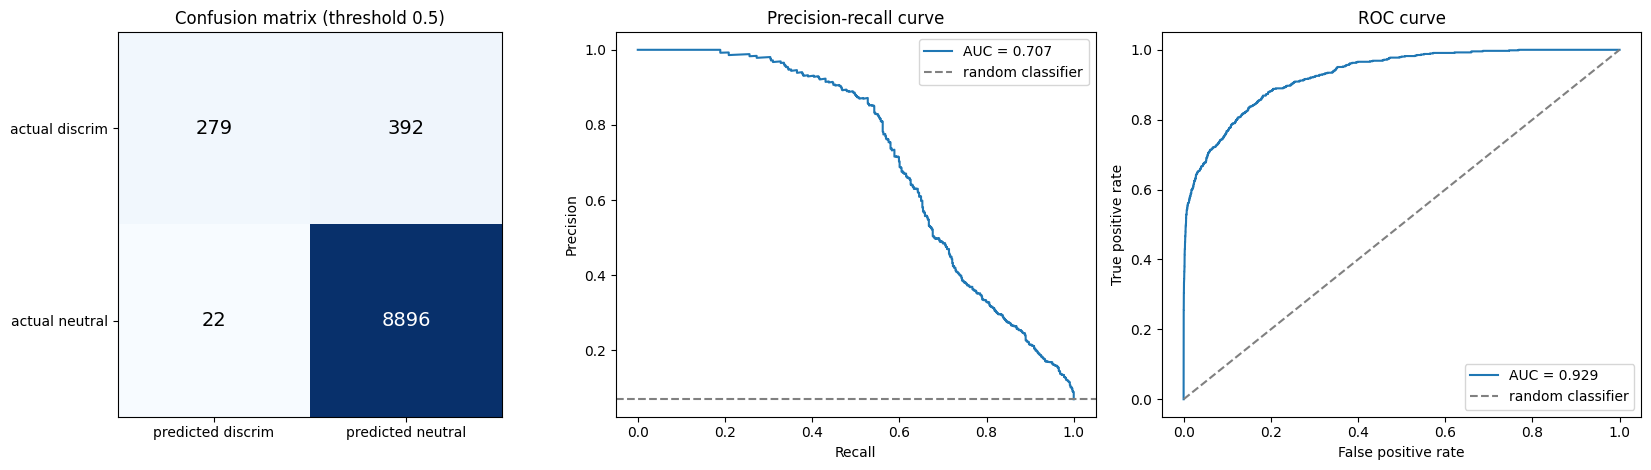

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

# Confusion matrix
m = naive_bayes_metrics
matrix = np.array([[m["tp"], m["fn"]], [m["fp"], m["tn"]]])
axes[0].imshow(matrix, cmap="Blues")
axes[0].set_xticks([0, 1], ["predicted discrim", "predicted neutral"])
axes[0].set_yticks([0, 1], ["actual discrim", "actual neutral"])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, matrix[i, j], ha="center", va="center", fontsize=14,
                     color="white" if matrix[i, j] > matrix.max() / 2 else "black")
axes[0].set_title("Confusion matrix (threshold 0.5)")

# Precision-recall curve
precisions, recalls, _ = precision_recall_curve(y_true, positive_scores)
axes[1].plot(recalls, precisions, label=f"AUC = {auc(recalls, precisions):.3f}")
axes[1].axhline(y_true.mean(), color="gray", linestyle="--", label="random classifier")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curve")
axes[1].legend()

# ROC curve
fpr, tpr, _ = roc_curve(y_true, positive_scores)
axes[2].plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}")
axes[2].plot([0, 1], [0, 1], color="gray", linestyle="--", label="random classifier")
axes[2].set_xlabel("False positive rate")
axes[2].set_ylabel("True positive rate")
axes[2].set_title("ROC curve")
axes[2].legend()

plt.tight_layout()
plt.show()

#### Effect of the decision threshold

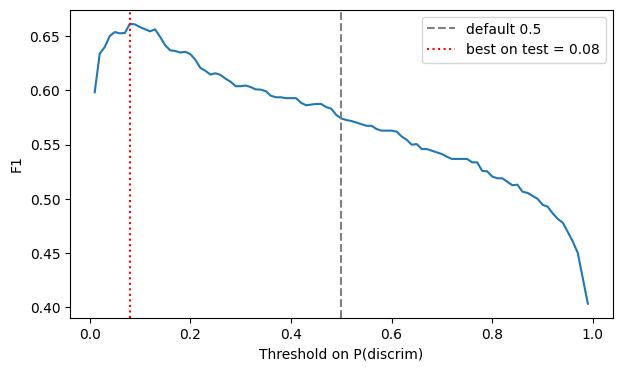

In [19]:
thresholds = np.linspace(0.01, 0.99, 99)
f1_per_threshold = [compute_metrics(y_true, positive_scores >= t)["f1"] for t in thresholds]
best_threshold = thresholds[int(np.argmax(f1_per_threshold))]

plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_per_threshold)
plt.axvline(0.5, color="gray", linestyle="--", label="default 0.5")
plt.axvline(best_threshold, color="red", linestyle=":", label=f"best on test = {best_threshold:.2f}")
plt.xlabel("Threshold on P(discrim)")
plt.ylabel("F1")
plt.legend()
plt.show()

The best threshold here is picked on the test set, so it is optimistic. It only shows how sensitive F1 is to the threshold. For a fair number, pick the threshold on a validation part of the train set.

With the default threshold the model is cautious: precision is high, recall is low. Lowering the threshold to about 0.08 trades some precision for much more recall and raises F1. The reason is the prior. Only 7% of the training tweets are `discrim`, so the model needs strong evidence before it says so.

#### Failure cases

In [20]:
test_df = discrimination_dataset.test_df

false_positives = np.where(~y_true & (positive_scores >= 0.5))[0]
false_negatives = np.where(y_true & (positive_scores < 0.5))[0]
print(f"False positives: {len(false_positives)}, false negatives: {len(false_negatives)}")

def show_cases(indices, title, count=5):
    print(f"\n{title}")
    for index in indices[:count]:
        print(f"P(discrim) = {positive_scores[index]:.3f} | {test_df['tweet'].iloc[index].strip()}")
        print(f"    useful words: {test_df['useful-words'].iloc[index]}")

# most confident mistakes first
show_cases(false_positives[np.argsort(-positive_scores[false_positives])],
           "Neutral tweets classified as discrim (most confident first)")
show_cases(false_negatives[np.argsort(positive_scores[false_negatives])],
           "Discrim tweets classified as neutral (most confident first)")

False positives: 22, false negatives: 392

Neutral tweets classified as discrim (most confident first)
P(discrim) = 1.000 | #lgbtqhatestrumppay but luvs homophobic misogynist antisemitic death cult masquerading as a religion.  !
    useful words: ['lgbtqhatestrumppay', 'luvs', 'homophobic', 'misogynist', 'antisemitic', 'death', 'cult', 'masquerading', 'religion']
P(discrim) = 0.999 | @user how did you slip through?  you are a threat to america  ! #bigotry #misogyny #ignorance #alwaystrup @user
    useful words: ['user', 'slip', 'threat', 'america', 'bigotry', 'misogyny', 'ignorance', 'alwaystrup', 'user']
P(discrim) = 0.988 | liberals are the most intolerant. they accuse conservatives of hate but they are full of hate and intolerance.  !
    useful words: ['liberals', 'intolerant', 'accuse', 'conservatives', 'hate', 'full', 'hate', 'intolerance']
P(discrim) = 0.982 | only 1 in 4, yes only 25% of republican voters polled believe what #trump said about judge curiel was racist.   #morning

Some of these errors look like label noise rather than model errors. Several tweets labelled `neutral` are clearly angry or accusing, and several labelled `discrim` read as ordinary chat. The model cannot fix that. It also means F1 has a ceiling below 1 on this dataset.

#### Why accuracy is a poor metric here

About 93% of the test tweets are `neutral`. The "always neutral" classifier gets accuracy 0.930 and finds no discriminatory tweet at all: recall 0, F1 0. Our classifier reaches 0.957. That is only 2.7 points above a model that does nothing, although it finds a good share of the positive class.

Accuracy counts every correct answer the same. The large class dominates the sum, so the rare class barely changes it. Precision and recall look only at the positive class, so the imbalance does not hide anything.

F1 is the harmonic mean of the two. It is low when either of them is low, and a high value of one cannot cover for the other. Our model has precision 0.93 and recall 0.42. Accuracy does not show the weak recall. F1 = 0.57 does.

ROC AUC (0.93) also looks better than the model deserves here. The false positive rate is divided by the large number of negatives, so it stays small. The precision-recall curve (AUC 0.71) is more honest for imbalanced data.

*All numbers in this section come from `classes_alpha = features_alpha = 1.0`. Re-run and update them after the final alphas are chosen.*

### Additional task

You are asked to explore, implement, evaluate, and analyze another way to calculate $\mathsf P(\text{text})$; mainly, by conditioning on the previous feature:
$$
\mathsf P(\text{text}) = \prod_{j=2}^N \mathsf P(\text{feature}_j \mid \text{feature}_{j-1}).
$$

The task will be graded proportionally to analysis depth and conclusions viability.

In [21]:
class BigramModel:
    """P(text | class) = prod P(word_j | word_{j-1}, class), with Laplace smoothing."""

    START = "<s>"

    def __init__(self, smoothing_alpha):
        self.alpha = smoothing_alpha
        self.pair_counts = {}
        self.previous_counts = {}
        self.vocabulary_size = 0

    def fit(self, dataset):
        vocabulary = set()
        for label_id, words in zip(dataset.train_df["label-id"], dataset.train_df["useful-words"]):
            pairs = self.pair_counts.setdefault(label_id, {})
            previous_totals = self.previous_counts.setdefault(label_id, {})
            previous = self.START
            for word in words:
                pairs[(previous, word)] = pairs.get((previous, word), 0) + 1
                previous_totals[previous] = previous_totals.get(previous, 0) + 1
                vocabulary.add(word)
                previous = word
        self.vocabulary_size = len(vocabulary)

    def log_probability(self, label_id, previous, word):
        pair_count = self.pair_counts[label_id].get((previous, word), 0)
        previous_count = self.previous_counts[label_id].get(previous, 0)
        return np.log((pair_count + self.alpha) / (previous_count + self.alpha * self.vocabulary_size))

    def predict(self, dataset, split, class_priors):
        df = dataset.train_df if split == "train" else dataset.test_df
        log_priors = np.log(class_priors)
        result = []
        for words in df["useful-words"]:
            numerators = []
            for label_id in range(len(log_priors)):
                total = log_priors[label_id]
                previous = self.START
                for word in words:
                    total += self.log_probability(label_id, previous, word)
                    previous = word
                numerators.append(total)
            numerators = np.array(numerators)
            result.append(np.exp(numerators - np.logaddexp.reduce(numerators)))
        return np.array(result)

In [22]:
class_priors = discrimination_dataset.calculate_classes_prior(classes_alpha)

bigram_alpha_grid = [0.01, 0.05, 0.1, 0.5, 1.0]
bigram_results = {}
for alpha in bigram_alpha_grid:
    model = BigramModel(alpha)
    model.fit(discrimination_dataset)
    scores = model.predict(discrimination_dataset, "test", class_priors)[:, positive_label_id]
    bigram_results[alpha] = (scores, compute_metrics(y_true, scores >= 0.5))

pd.DataFrame({f"bigram alpha={a}": r[1] for a, r in bigram_results.items()}).T

,tp,fp,fn,tn,accuracy,precision,recall,f1
bigram alpha=0.01,379.0,645.0,292.0,8273.0,0.902284,0.370117,0.564829,0.447198
bigram alpha=0.05,295.0,125.0,376.0,8793.0,0.947753,0.702381,0.439642,0.540788
bigram alpha=0.1,279.0,58.0,392.0,8860.0,0.953071,0.827893,0.415797,0.553571
bigram alpha=0.5,225.0,2.0,446.0,8916.0,0.953280,0.991189,0.335320,0.501114
bigram alpha=1.0,187.0,0.0,484.0,8918.0,0.949525,1.000000,0.278689,0.435897


In [23]:
best_bigram_alpha = max(bigram_results, key=lambda a: bigram_results[a][1]["f1"])
bigram_scores = bigram_results[best_bigram_alpha][0]

comparison = pd.DataFrame({
    "unigram": naive_bayes_metrics,
    f"bigram (alpha={best_bigram_alpha})": bigram_results[best_bigram_alpha][1],
}).T
comparison["pr_auc"] = [auc(*precision_recall_curve(y_true, s)[1::-1]) for s in (positive_scores, bigram_scores)]
comparison["roc_auc"] = [auc(*roc_curve(y_true, s)[:2]) for s in (positive_scores, bigram_scores)]
comparison

,tp,fp,fn,tn,accuracy,precision,recall,f1,pr_auc,roc_auc
unigram,279.0,22.0,392.0,8896.0,0.956826,0.926910,0.415797,0.574074,0.707359,0.928918
bigram (alpha=0.1),279.0,58.0,392.0,8860.0,0.953071,0.827893,0.415797,0.553571,0.571721,0.864835


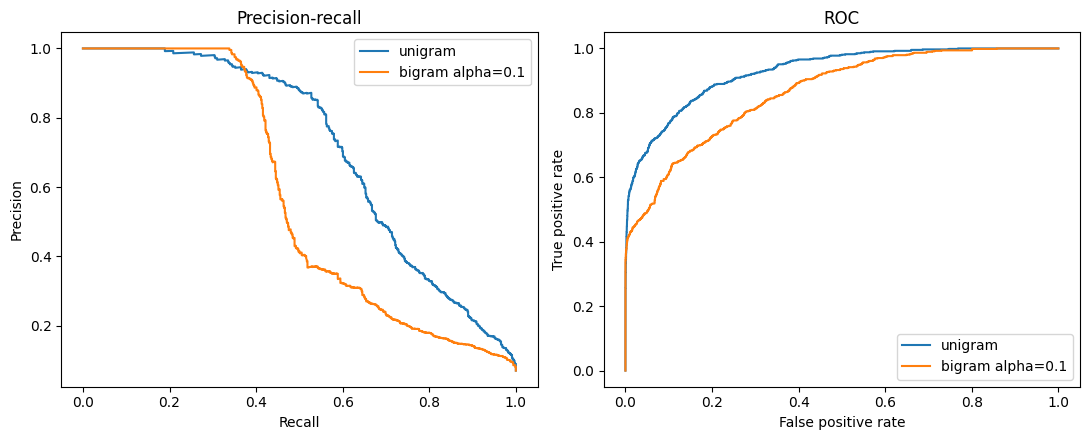

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for name, scores in (("unigram", positive_scores), (f"bigram alpha={best_bigram_alpha}", bigram_scores)):
    precisions, recalls, _ = precision_recall_curve(y_true, scores)
    axes[0].plot(recalls, precisions, label=name)
    fpr, tpr, _ = roc_curve(y_true, scores)
    axes[1].plot(fpr, tpr, label=name)
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision"); axes[0].set_title("Precision-recall"); axes[0].legend()
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate"); axes[1].set_title("ROC"); axes[1].legend()
plt.tight_layout()
plt.show()

In [25]:
# How sparse is the bigram model? Share of test items that were never seen in train.
def to_bigrams(words):
    return list(zip([BigramModel.START] + words[:-1], words))

train_words = set(w for words in discrimination_dataset.train_df["useful-words"] for w in words)
train_bigrams = set(b for words in discrimination_dataset.train_df["useful-words"] for b in to_bigrams(words))

test_words = [w for words in test_df["useful-words"] for w in words]
test_bigrams = [b for words in test_df["useful-words"] for b in to_bigrams(words)]

print(f"Unseen words in test:   {np.mean([w not in train_words for w in test_words]):.1%}")
print(f"Unseen bigrams in test: {np.mean([b not in train_bigrams for b in test_bigrams]):.1%}")

Unseen words in test:   11.0%
Unseen bigrams in test: 57.4%


#### Bigram model: analysis

The bigram model is not better than the unigram model here. Its best F1 is 0.55 against 0.57, and its PR AUC is 0.57 against 0.71.

The main reason is sparsity. Tweets are short, about ten useful words. About 11% of the test words never appear in train, but about 57% of the test bigrams do not. For those bigrams the model relies on smoothing alone. The probability of an unseen bigram depends on how often the previous word was seen in that class. This count differs between classes, so the smoothing term itself pushes the decision one way or the other.

The bigram model is also very sensitive to `alpha`. With `alpha = 0.01` recall is high and precision is low. With `alpha = 1.0` there are no false positives, but recall drops below 0.3. The unigram model is much more stable, because every word has enough counts.

Limits of this comparison. `alpha` for the bigram model was chosen on the test set, which favours the bigram model, and it still does not win. Bigrams are built from the filtered word list, so two words that are neighbours after stop-word removal were not always neighbours in the tweet. A larger dataset, or backing off from bigram to unigram probabilities, would likely help.

### Conclusions

**Method.** We classify tweets as `discrim` or `neutral` with a Naive Bayes classifier. It uses Bayes' theorem: $\mathsf P(\text{class}_i \mid \text{text}) \propto \mathsf P(\text{class}_i)\,\mathsf P(\text{text} \mid \text{class}_i)$. The word probabilities are estimated from counts in the training data. The "naive" assumption is that words are independent given the class, so the likelihood is a product over words. We work in the log domain, so the product becomes a sum and does not underflow. Laplace smoothing is applied to the class priors and to the word probabilities, so unseen words do not give zero. The evidence is computed with `logaddexp`, which normalizes the probabilities to sum to 1.

**Pros.** The model is simple and fast: training is one pass of counting. It has few parameters to tune (two smoothing values). It is easy to interpret, because every word has a per-class probability. It works with little data.

**Cons and assumptions.** Independence of words is false for language, so the probabilities are not calibrated and are often close to 0 or 1. The model ignores word order and context, so it cannot see sarcasm or negation. The word probabilities assume the test data looks like the train data. Preprocessing removes numbers, emoji and non-latin characters, and they are lost. The classes are imbalanced (7% positive), so the prior pushes predictions toward `neutral` and recall is low at threshold 0.5. The labels look noisy in some places, which limits every metric. The bigram extension did not help on this dataset because of sparsity.

**Accuracy and F1.** Accuracy is a poor metric for imbalanced data. A classifier that always answers `neutral` gets 0.930 accuracy, and our model gets 0.957. F1 is the harmonic mean of precision and recall and is low if either is low. It is 0 for the trivial classifier and 0.57 for ours, which shows the real quality. On imbalanced data, F1 and the precision-recall curve should be the main metrics.